# Notebook 03

# Análisis, Visualización y Conclusiones

Proyecto:
Análisis ENAHO 2025

Objetivo:
Analizar el conjunto de datos después del tratamiento de valores atípicos mediante estadísticas descriptivas y visualizaciones para obtener conclusiones.

In [1]:
# =====================================
# LIBRERÍAS
# =====================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# =====================================
# CARGA DEL DATASET
# =====================================

ruta = "../data/processed/datos_sin_outliers.csv"

df = pd.read_csv(ruta)

print(f"Dimensiones del dataset: {df.shape}")

df.head()

Dimensiones del dataset: (16044, 13)


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
0,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0
1,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0
2,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0
3,2,5.0,7.0,2.0,6.0,4,8,6,2.0,64.0,0.000000,3,2.0
4,1,5.0,7.0,2.0,4.0,4,8,6,0.0,76.0,0.000000,3,1.0


In [3]:
# =====================================
# EXPLORACIÓN DEL DATASET
# =====================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16044 entries, 0 to 16043
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PERCEPHO        16044 non-null  int64  
 1   P103            16044 non-null  float64
 2   P104            16044 non-null  float64
 3   P105A           16044 non-null  float64
 4   EDUCACION_JEFE  16044 non-null  float64
 5   DOMINIO         16044 non-null  int64  
 6   NUM_SERVICIOS   16044 non-null  int64  
 7   NUM_EQUIPOS     16044 non-null  int64  
 8   NUM_OCUPADOS    16044 non-null  float64
 9   EDAD_JEFE       16044 non-null  float64
 10  PCT_NINOS       16044 non-null  float64
 11  POBREZA         16044 non-null  int64  
 12  HACINAMIENTO    16044 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 1.6 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PERCEPHO,16044.0,1.809150,0.726160,0.000,1.0,2.0,2.0,3.000
P103,16044.0,4.669097,1.244980,1.000,4.0,5.0,6.0,7.000
P104,16044.0,3.342184,1.422244,1.000,2.0,3.0,4.0,7.000
P105A,16044.0,2.000000,0.000000,2.000,2.0,2.0,2.0,2.000
EDUCACION_JEFE,16044.0,5.390115,2.345324,1.000,4.0,5.0,6.0,10.000
DOMINIO,16044.0,4.850536,2.337795,1.000,3.0,5.0,7.0,8.000
NUM_SERVICIOS,16044.0,8.000000,0.000000,8.000,8.0,8.0,8.0,8.000
NUM_EQUIPOS,16044.0,6.000000,0.000000,6.000,6.0,6.0,6.0,6.000
NUM_OCUPADOS,16044.0,1.485789,0.851930,0.000,1.0,1.0,2.0,3.000
EDAD_JEFE,16044.0,57.597731,15.083445,17.000,46.0,58.0,69.0,98.000


In [5]:
df.isnull().sum()

PERCEPHO          0
P103              0
P104              0
P105A             0
EDUCACION_JEFE    0
DOMINIO           0
NUM_SERVICIOS     0
NUM_EQUIPOS       0
NUM_OCUPADOS      0
EDAD_JEFE         0
PCT_NINOS         0
POBREZA           0
HACINAMIENTO      0
dtype: int64

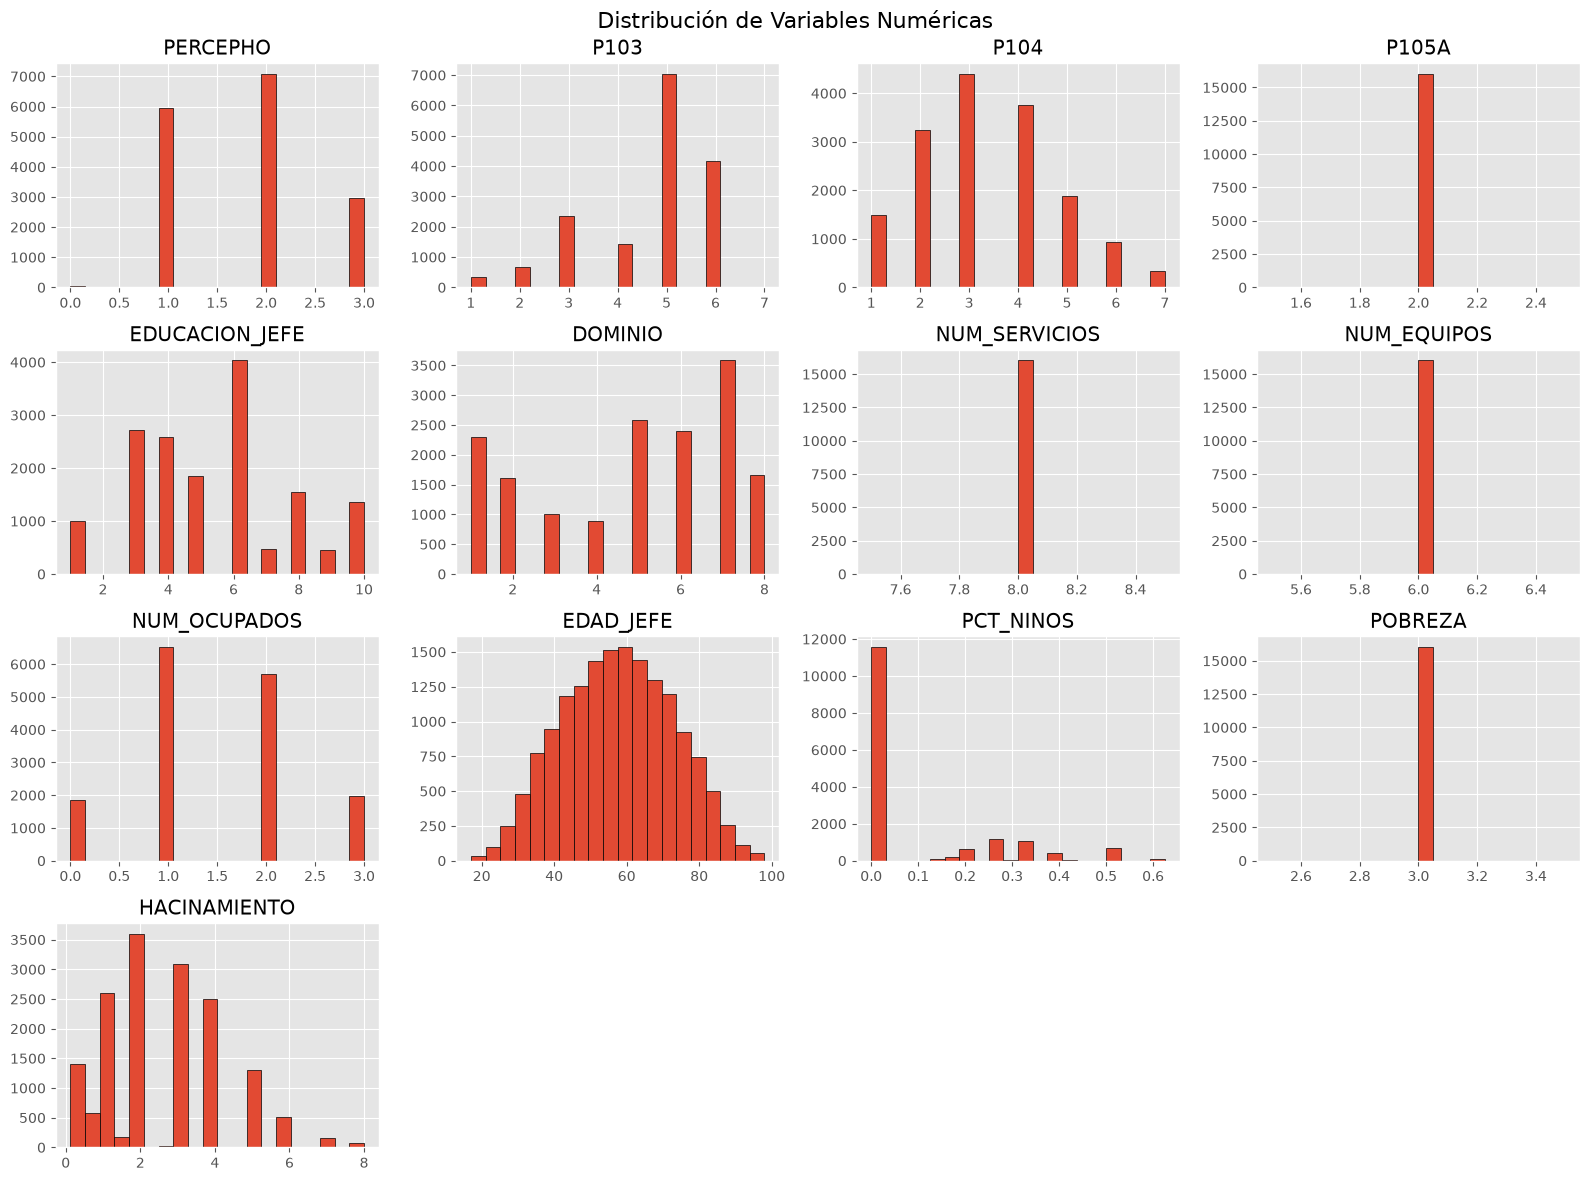

In [6]:
# =====================================
# HISTOGRAMAS DE VARIABLES NUMÉRICAS
# =====================================

variables = df.select_dtypes(include=np.number).columns

df[variables].hist(
    figsize=(16, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.tight_layout()

# Guardar figura
plt.savefig("../figures/analisis_histogramas.png", dpi=300, bbox_inches="tight")

plt.show()

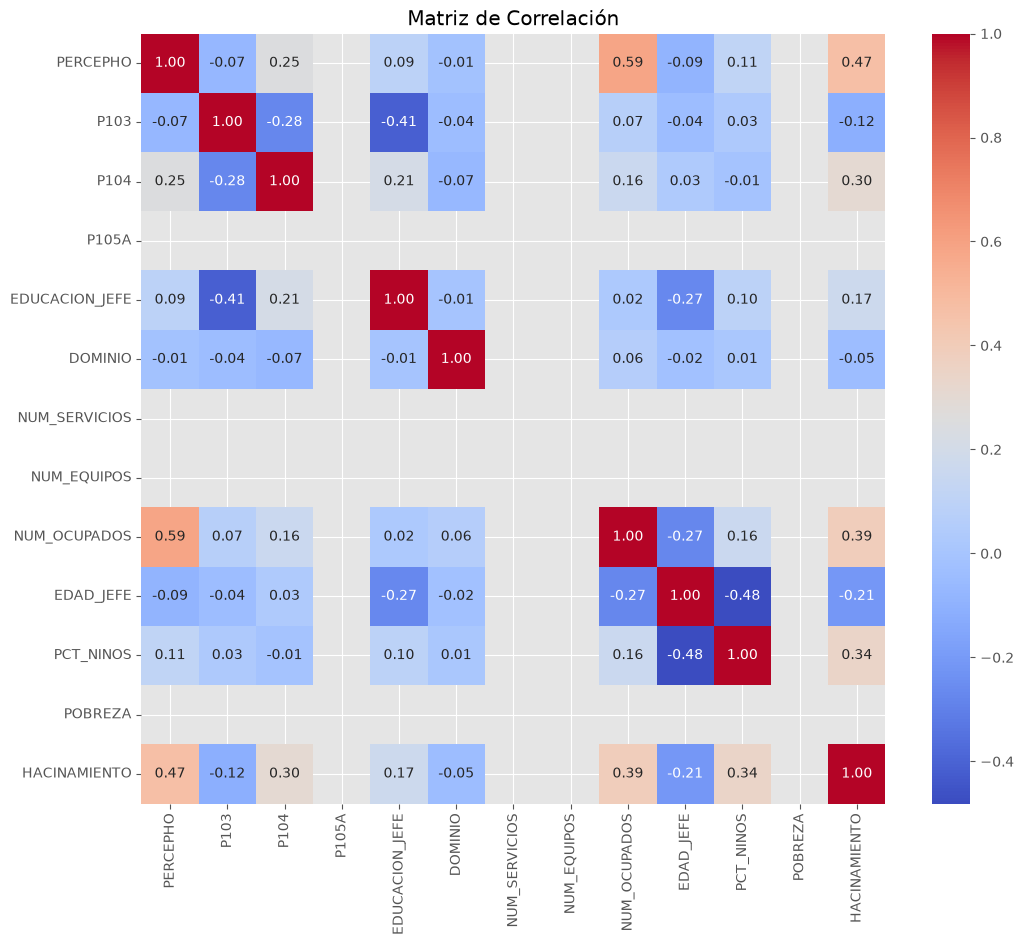

In [7]:
# =====================================
# MATRIZ DE CORRELACIÓN
# =====================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación")

# Guardar figura
plt.savefig("../figures/analisis_correlacion.png", dpi=300, bbox_inches="tight")

plt.show()

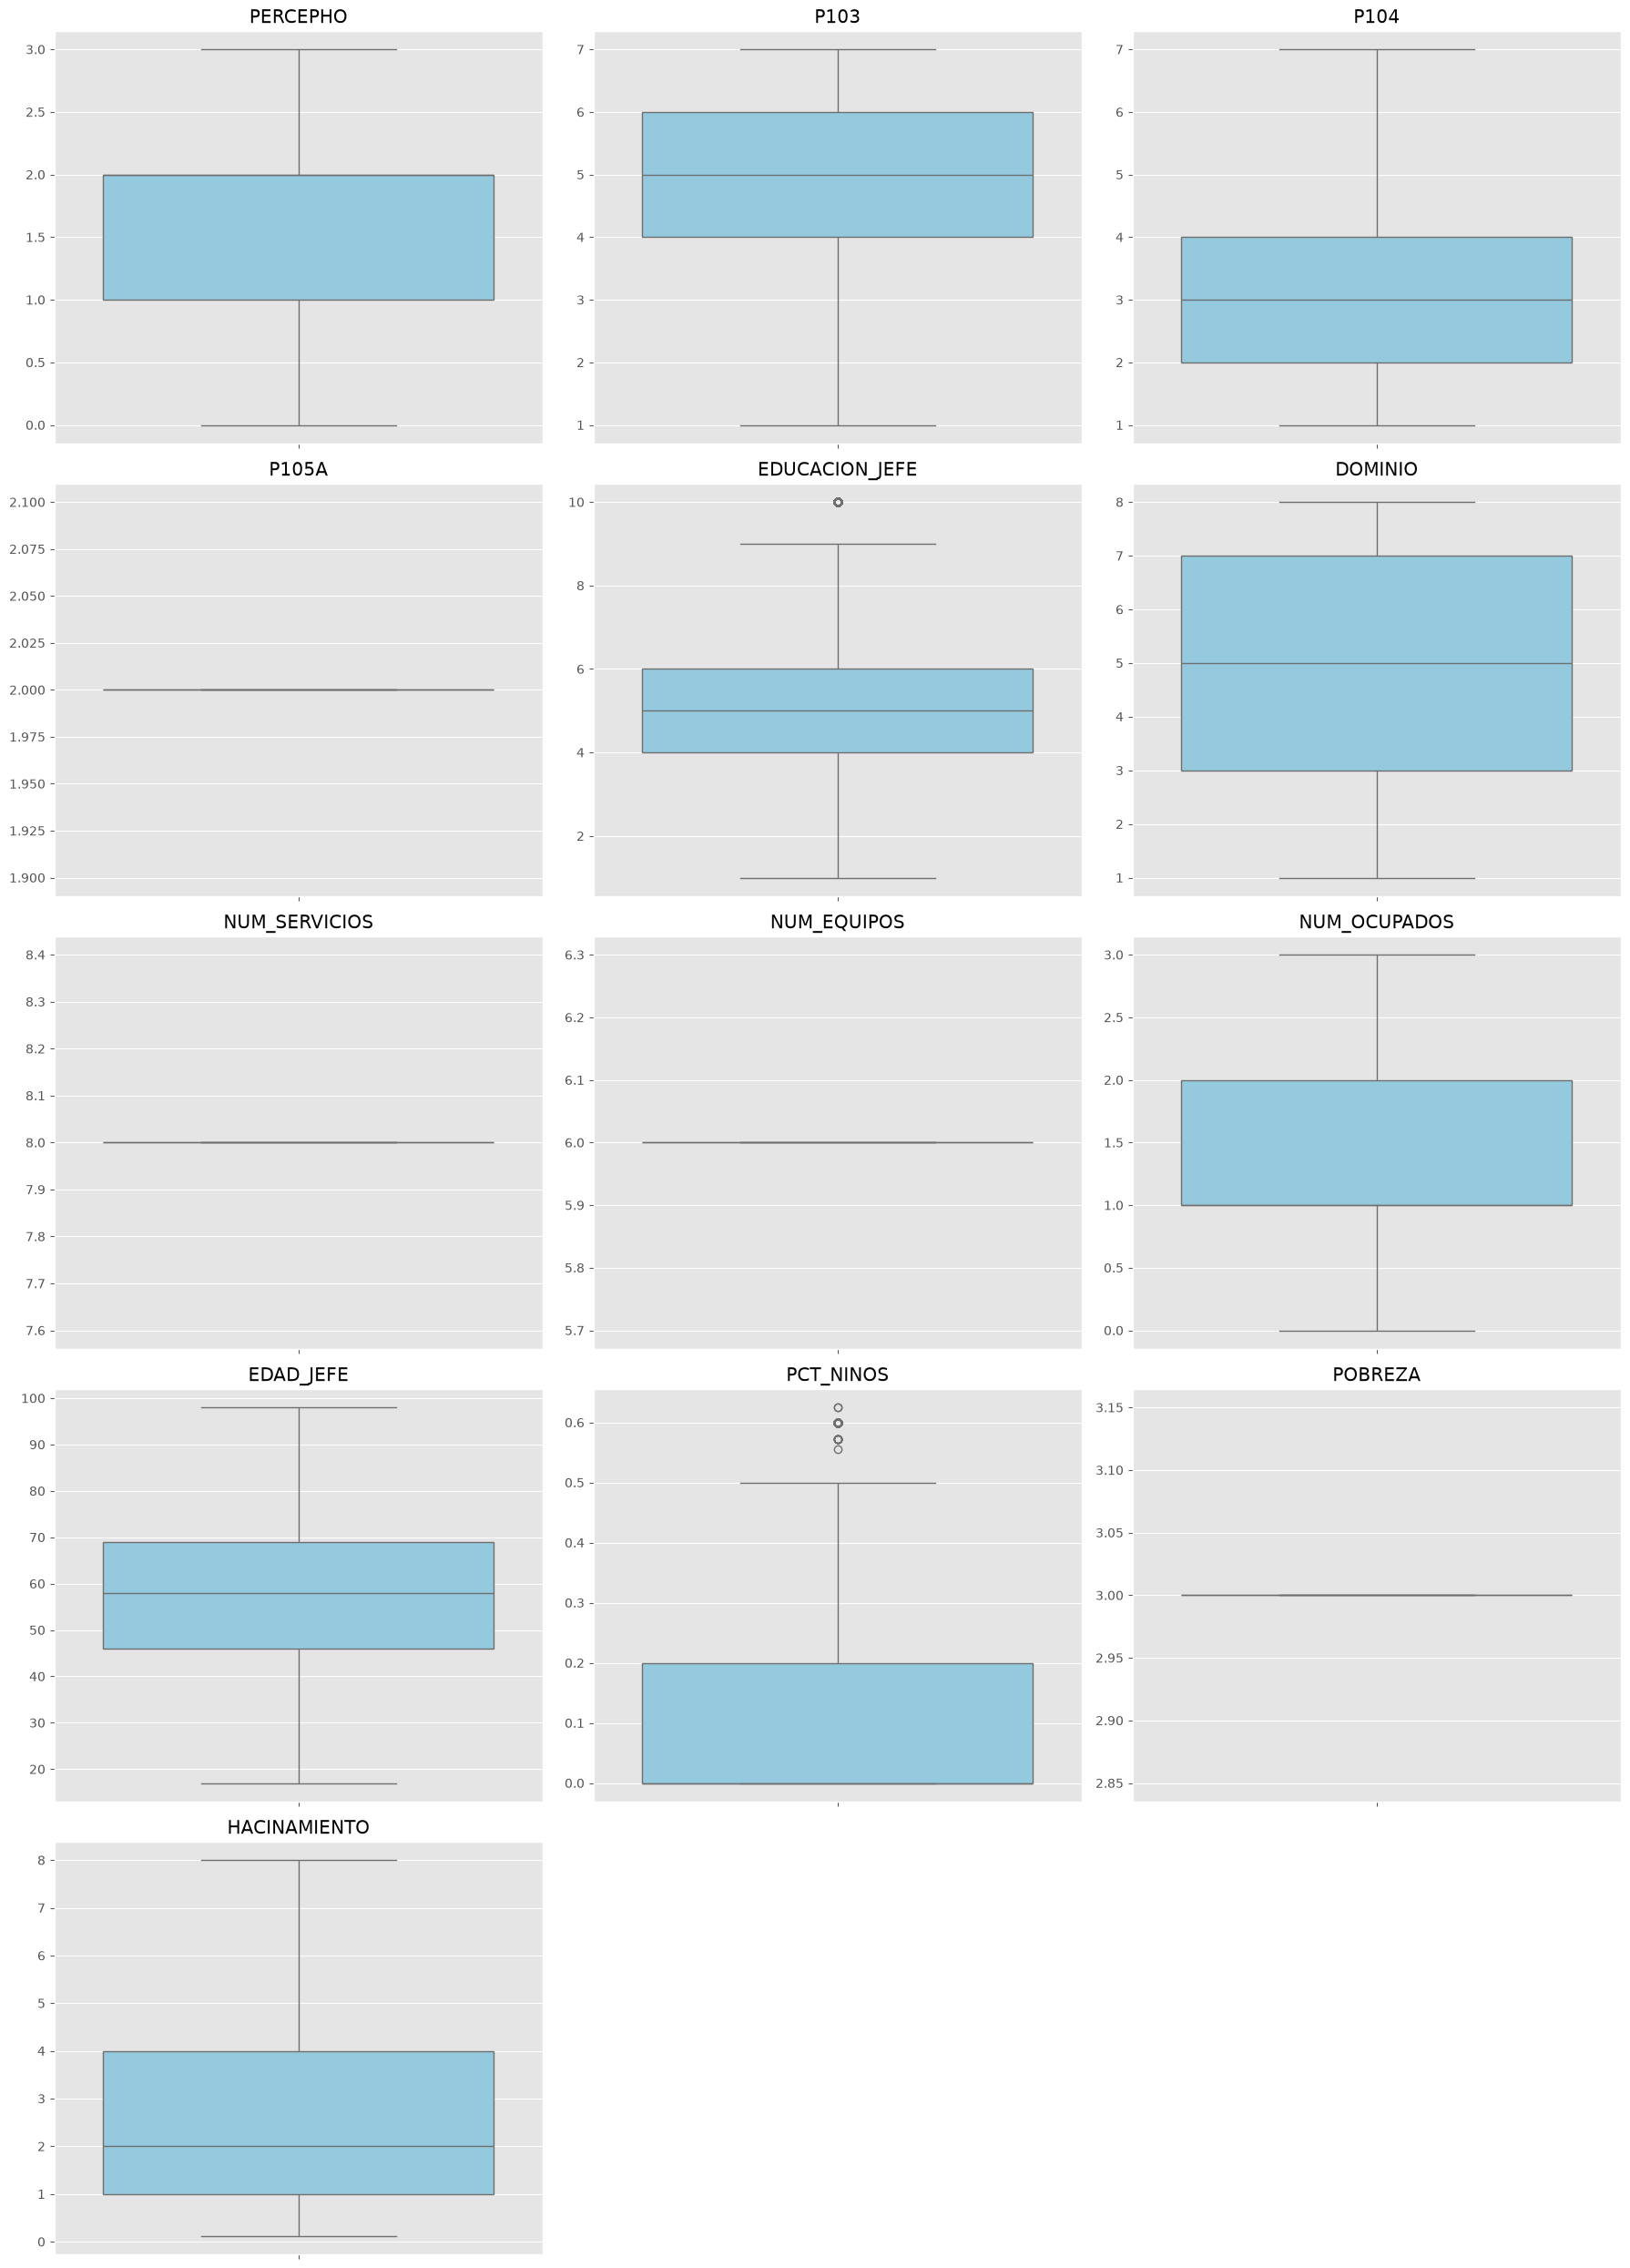

In [8]:
# =====================================
# BOXPLOTS DE VARIABLES NUMÉRICAS
# =====================================

import math

variables = df.select_dtypes(include=np.number).columns

columnas = 3
filas = math.ceil(len(variables) / columnas)

fig, axes = plt.subplots(filas, columnas, figsize=(18, 5 * filas))
axes = axes.flatten()

for i, variable in enumerate(variables):
    sns.boxplot(
        y=df[variable],
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(variable)
    axes[i].set_ylabel("")

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Guardar figura
plt.savefig(
    "../figures/analisis_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# =====================================
# RESUMEN ESTADÍSTICO
# =====================================

resumen = df.describe().T

display(resumen)

resumen.to_csv(
    "../data/processed/resumen_estadistico.csv"
)

print("✅ Resumen estadístico exportado correctamente.")

,count,mean,std,min,25%,50%,75%,max
PERCEPHO,16044.0,1.809150,0.726160,0.000,1.0,2.0,2.0,3.000
P103,16044.0,4.669097,1.244980,1.000,4.0,5.0,6.0,7.000
P104,16044.0,3.342184,1.422244,1.000,2.0,3.0,4.0,7.000
P105A,16044.0,2.000000,0.000000,2.000,2.0,2.0,2.0,2.000
EDUCACION_JEFE,16044.0,5.390115,2.345324,1.000,4.0,5.0,6.0,10.000
DOMINIO,16044.0,4.850536,2.337795,1.000,3.0,5.0,7.0,8.000
NUM_SERVICIOS,16044.0,8.000000,0.000000,8.000,8.0,8.0,8.0,8.000
NUM_EQUIPOS,16044.0,6.000000,0.000000,6.000,6.0,6.0,6.0,6.000
NUM_OCUPADOS,16044.0,1.485789,0.851930,0.000,1.0,1.0,2.0,3.000
EDAD_JEFE,16044.0,57.597731,15.083445,17.000,46.0,58.0,69.0,98.000


✅ Resumen estadístico exportado correctamente.


# =====================================
# CONCLUSIONES
# =====================================

## Conclusiones

Durante esta etapa se realizó el análisis exploratorio del conjunto de datos luego del tratamiento de valores atípicos. Las principales observaciones fueron las siguientes:

- El conjunto de datos limpio permitió obtener estadísticas descriptivas más representativas de la población analizada.
- Los histogramas mostraron la distribución de las variables numéricas, facilitando la identificación de su comportamiento.
- La matriz de correlación permitió identificar relaciones entre las variables cuantitativas utilizadas en la investigación.
- Los boxplots confirmaron que la presencia de valores extremos disminuyó después del tratamiento de outliers realizado en el Notebook 02.
- El resumen estadístico generado servirá como base para la interpretación de resultados y el desarrollo del informe final.